In [20]:
from matplotlib import pyplot as plt
import json

from pathlib import Path

import pandas as pd

import numpy as np 


from scipy.stats import sem

In [53]:
DIR = Path("../../artifacts/2023-08-s10/experiments/accuracy-basis-wb15")

In [54]:
def load(dataset, arch, layer, basis_name, training_size=1.0, logit_mod="oneclass", basis_mode="centered", seeds=[1]):
    
    arr_dfs = []
    for seed in seeds:
#         print(f"training-size={training_size}")
        with open(DIR / f"{dataset}--ts{training_size}-seed{seed}" / f"logit-mod-{logit_mod}" / arch / layer / f"{basis_name}--{basis_mode}" / "stats.json", "r") as fh:
            data = json.load(fh)
            
        
        df = pd.DataFrame(
            {
                "acc": data["arr_acc"],
                "k": data["arr_ks"],
            }
        )
        df["dims"] = data["dims"]

        # remark: the attribute name here is misnormzer. 
        # perhaps, we refactor it.
        df["original_acc"] = data["original_auroc"]
        df["seed"] = seed
            
        arr_dfs.append(df)
    
    df = pd.concat(arr_dfs).groupby(by="k").agg({
        "acc": ["mean", "std"],
        "seed": ["count"],
        "original_acc": ["first"],
        "dims": ["first"]
    })
    
    
    assert (df["seed"]["count"] == df["seed"]["count"].values[0]).all()

    for col in ["original_acc", "dims"]:

        assert (df[col]["first"] == df[col]["first"].values[0]).all()

    return df.reset_index()

_df = load(
    dataset="cifar100-fish", 
    arch="cifar100-resnet18-wb15e151",
    layer="layer3", 
    basis_name="pca", 
    training_size=1.0
)

_df[5:10]

k    acc      seed original_acc  dims
        mean std count        first first
5   6  0.394 NaN     1         0.87   256
6   7  0.442 NaN     1         0.87   256
7   8  0.534 NaN     1         0.87   256
8   9  0.580 NaN     1         0.87   256
9  10  0.622 NaN     1         0.87   256

# Accuracy Basis Curve

## One Class Curve

In [55]:
def color(name):
    if "random" in name:
        return "lightgray"
    elif name in ["rel-abs", "rel-recon", "rel-reconnaive"]  or name in ["act-recon", "act-abs"]:
        return plt.gca().lines[-1].get_color()
    else:
        return None

def marker(name):
    if name in ["pca", "prca-abs", "prca-recon", 'rel-recon', "act-recon"]:
        return "."
    elif "pcaprca" in name:
        return "s"
    elif name in ["rel-reconnaive", "prca-reconnaive"]:
        return "|"
    else:
        return None
    
def ls(name):
    if "rel" in name or "act" in name:
        return "--"
    elif "random" in name:
        return ":"
    else:
        return "-"
def viz_basis_accuracy_curve(
    dataset, 
    arch = "cifar100-resnet18-p1",
    layers=["layer3", "layer4"],
    basis_names=[
        "pca",
        "prca-recon",
        "pcaprca-recon",
        "prca-abs", 
        'pcaprca-abs',
        "rel", 
        "rel-abs",
        "random", 
        
    ],
    verbose=False
):
    

    ncols = len(layers)
    plt.figure(figsize=(ncols * 5, 4))
    
    ii = 6
    
    for lix, layer in enumerate(layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)
        if lix == 0:
            plt.ylabel("Accuracy")
        for bix, basis_name in enumerate(basis_names):
            df = load(
                dataset=dataset, arch=arch, layer=layer, basis_name=basis_name
            )
            d = df["dims"]["first"].values[-1]
            k = df.k
            max_k =  np.floor(np.log2(k.max()))
            power_of_two = np.power(2, np.arange(1, max_k+1))

            nseeds = df["seed"]["count"].values[-1]

            if bix == 0:
                teacher_metric = df["original_acc"]["first"].values[-1]

                plt.axhline(teacher_metric, ls='-', lw=1, color="k", label="Teacher")
            
            
            vcolor = color(basis_name)
            
            if "pcaprca" in basis_name:
                vcolor = plt.gca().lines[-1].get_color()
            
            stderr = df["acc"]["std"] / (nseeds ** 0.5)
            mean = df["acc"]["mean"]
            if verbose:
                print(f"[layer={layer}; {basis_name:20s}]: {np.around(mean.values[:10], decimals=4)}")
#             print(k)
#             selected = k.isin(power_of_two)
            selected = [True] * k.shape[0]
            plt.plot(
                k[selected],
                mean[selected],
                label=f"{basis_name}(@k{k[ii]}={mean.values[ii]:.2f})" if verbose else basis_name,
                color=vcolor,
                ls=ls(basis_name),
                marker=marker(basis_name)
            )
            
            plt.fill_between(
                k[selected],
                (mean - stderr)[selected],
                (mean + stderr)[selected],
                alpha=0.5
            )
        
        for p in np.array(power_of_two):
                              
            plt.axvline(
                int(p), 
                ls="-", 
                lw=0.5,
                alpha=0.1,
                color="k", 
            )
        
        plt.xlabel(f"Number of Components (d={d})")

#         if lix == len(layers) - 1:
        plt.legend(
#             bbox_to_anchor=(1.0,1)
        )
            
    slug = "/".join(f"{DIR}".split("/")[-2:])
    plt.suptitle(f"dir: {slug}\n{arch}: {dataset}", y=1.2)

# viz_basis_accuracy_curve(
#     dataset="cifar100-people",
#     arch = "cifar100-resnet18-p1",
#     layers=["layer3", "layer4"],
#     basis_names=[
#         "pca",
#         "prca-abs",
#         "prca-reconnaive",
#         "prca-recon",
#         "pcaprca-recon",
        
#         'act-raw',
#         'act-recon',
#         'rel-raw',
#         'rel-reconnaive',
#         'rel-recon',
#         "random",
#     ]
# )


In [56]:
CIFAR100_SUPERCLASSES = """
cifar100-aquatic_mammals
cifar100-fish
cifar100-flowers
cifar100-food_containers
cifar100-fruit_and_vegetables
cifar100-household_electrical_devices
cifar100-household_furniture
cifar100-insects
cifar100-large_carnivores
cifar100-large_man_made_outdoor_things
cifar100-large_natural_outdoor_scenes
cifar100-large_omnivores_and_herbivores
cifar100-medium_mammals
cifar100-non_insect_invertebrates
cifar100-people
cifar100-reptiles
cifar100-small_mammals
cifar100-trees
cifar100-vehicles_1
cifar100-vehicles_2
""".strip().split("\n")

CIFAR100_SUPERCLASSES

['cifar100-aquatic_mammals',
 'cifar100-fish',
 'cifar100-flowers',
 'cifar100-food_containers',
 'cifar100-fruit_and_vegetables',
 'cifar100-household_electrical_devices',
 'cifar100-household_furniture',
 'cifar100-insects',
 'cifar100-large_carnivores',
 'cifar100-large_man_made_outdoor_things',
 'cifar100-large_natural_outdoor_scenes',
 'cifar100-large_omnivores_and_herbivores',
 'cifar100-medium_mammals',
 'cifar100-non_insect_invertebrates',
 'cifar100-people',
 'cifar100-reptiles',
 'cifar100-small_mammals',
 'cifar100-trees',
 'cifar100-vehicles_1',
 'cifar100-vehicles_2']

## Accuracy Curve Aggregated Over Classes

In [57]:
def basis_displayname(basis_name):
    mapping = {
        "random": "Random",
        "act-recon": "Act",
        "rel-recon": "Rel",
        "pca": "PCA",
        'pcaprca-recon': "PRCA"
    }

    return f"{mapping.get(basis_name, basis_name):15s}"


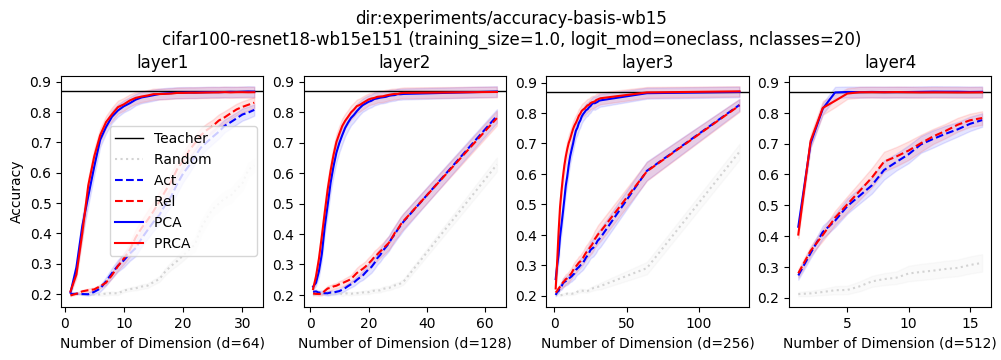

In [58]:
def accuracy_curve(
    arch, layers_and_factors,
    arr_classes=CIFAR100_SUPERCLASSES,
    arr_bases = [
        "random",
        "act-recon",
        "rel-recon",
        "pca",
        "pcaprca-recon",
    ],
    logit_mod="oneclass",
    training_size=1.0
):


        
    ncols = len(layers_and_factors)
    
    plt.figure(figsize=(ncols * 3, 3))
    plt.suptitle("\n".join([
        "dir:" + "/".join(f"{DIR}".split("/")[-2:]),
        f"{arch} (training_size={training_size}, logit_mod={logit_mod}, nclasses={len(arr_classes)})"
    ]), y=1.1)
    
    def color(basis_name):
        if basis_name in ["act-recon", "pca"]:
            return "blue"
        elif basis_name in ["rel-recon", "pcaprca-recon"]:
            return "red"
        elif "random" == basis_name:
            return "lightgray"
        else:
            return "green"
            raise NotImplementedError(f"no color for `{basis_name}`")
            
    def ls(basis_name):
        if basis_name == "random":
            return ":"
        elif basis_name in ["act-recon", "rel-recon"]:
            return "--"
        else:
            return "-"
        
    
    for lix, (layer, factor) in enumerate(layers_and_factors):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)

        teacher_stats = []
        for dataset in arr_classes:
            df = load(
                dataset=dataset,  arch=arch, layer=layer,  basis_name="random",  training_size=training_size,
                logit_mod=logit_mod,
            )
            acc = df["original_acc"]["first"].values
            np.testing.assert_equal(acc[0], acc)
            teacher_stats.append(acc[0])
        
        mean_teacher = np.mean(teacher_stats)
        stderr_teacher = sem(teacher_stats)

        assert mean_teacher.shape == stderr_teacher.shape == ()

        plt.axhline(mean_teacher, label="Teacher", color="k", lw=1, ls="-")

        for basis_name in arr_bases:
            stats = []
            for dataset in arr_classes:
                df = load(
                    dataset=dataset, 
                    arch=arch,
                    layer=layer, 
                    basis_name=basis_name, 
                    training_size=training_size,
                    logit_mod=logit_mod,
                )
                    
                    
                d = df["dims"]["first"].values[0]
                stats.append(df["acc"]["mean"].values)
                k = df["k"].values
            
            stats = np.array(stats)
            
            selected = k <= d//factor
            
            assert stats.shape == (len(arr_classes), len(k))
            
            mean_stats = np.mean(stats, axis=0)
            stderr_stats = sem(stats, axis=0)
            assert stderr_stats.shape == mean_stats.shape
#             print(stats.shape)

            _k = k[selected]
            _mean = mean_stats[selected]
            _stderr = stderr_stats[selected]
            plt.plot(
                _k,
                _mean, 
                label=basis_displayname(basis_name),
                color=color(basis_name),
                ls=ls(basis_name)
            )
    
            plt.fill_between(
                _k,
                _mean - _stderr,
                _mean + _stderr,
                color=plt.gca().lines[-1].get_color(),
                alpha=0.1
            )
                                
            
            
            
        plt.xlabel(f"Number of Dimension (d={d})")
        if lix == 0:
            plt.ylabel("Accuracy")
            plt.legend()

            
accuracy_curve(
    arch="cifar100-resnet18-wb15e151",
    layers_and_factors = [
        ("layer1", 2),
        ("layer2", 2),
        ("layer3", 2),
        ("layer4", 32)
    ]
)

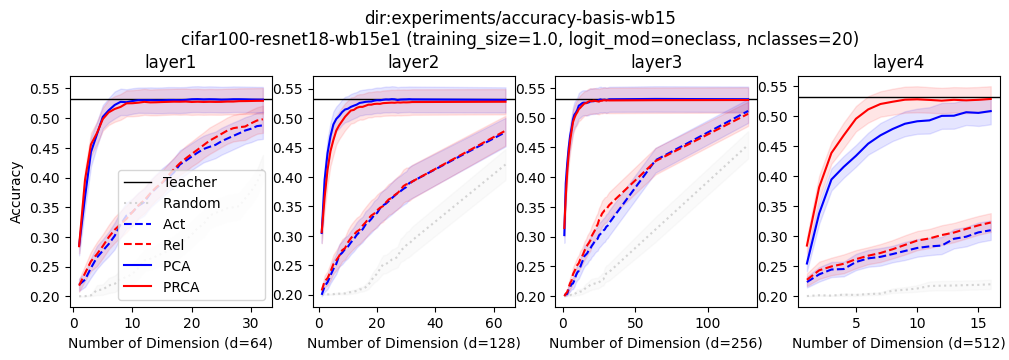

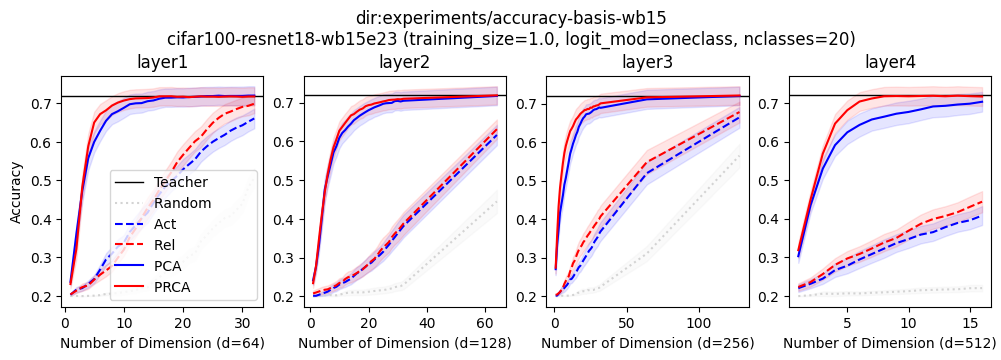

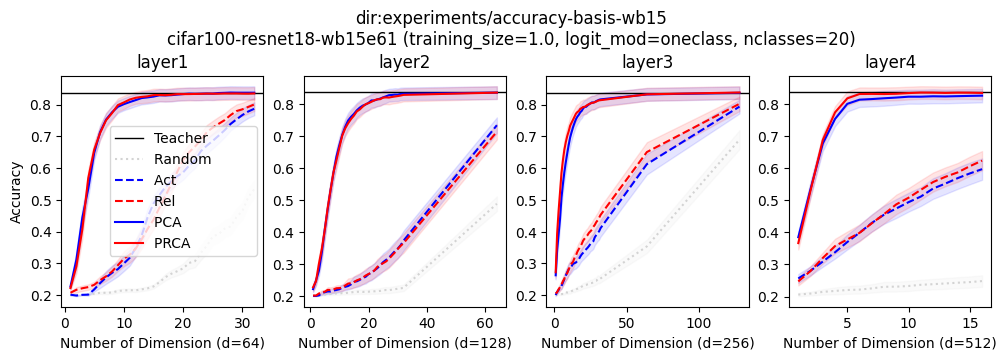

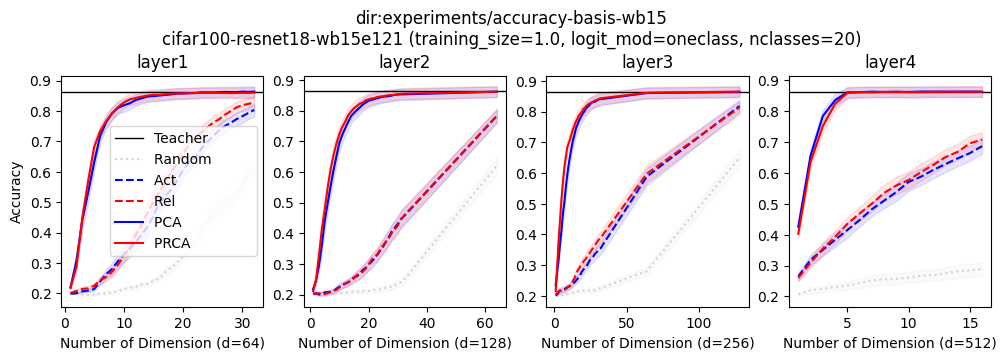

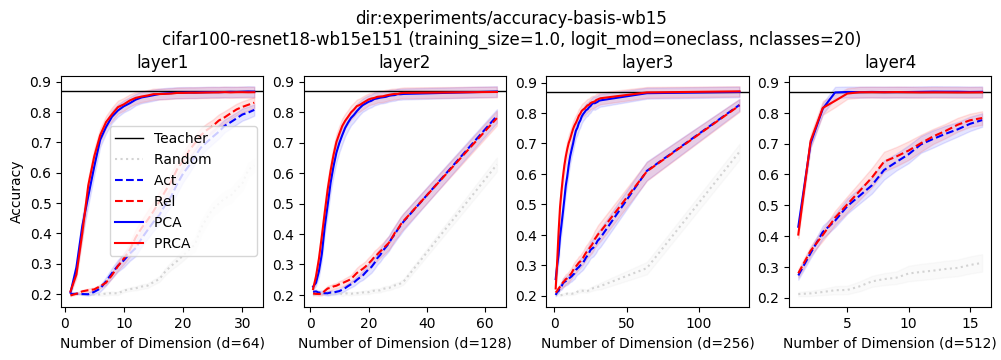

In [67]:
for epoch in [1, 23, 61, 121, 151]:
    accuracy_curve(
        arch=f"cifar100-resnet18-wb15e{epoch}",
        layers_and_factors = [
            ("layer1", 2),
            ("layer2", 2),
            ("layer3", 2),
            ("layer4", 32)
        ],
    )

## COmparing Training Size

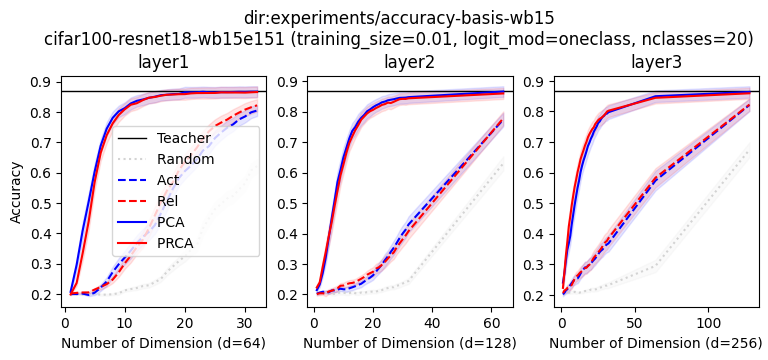

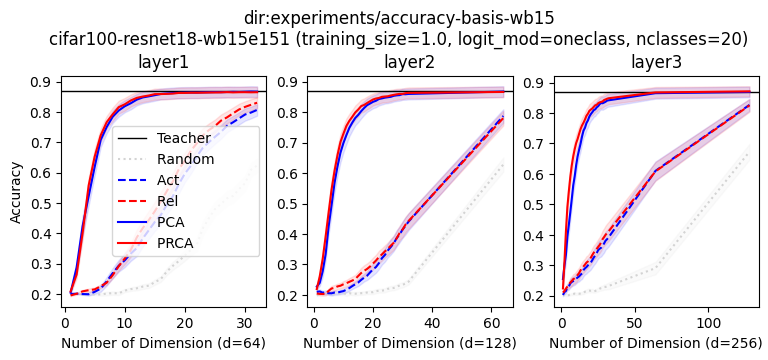

In [69]:
for training_size in [0.01, 1.0]:
    accuracy_curve(
        arch="cifar100-resnet18-wb15e151",
        layers_and_factors = [
            ("layer1", 2),
            ("layer2", 2),
            ("layer3", 2),
#             ("layer4", 32)
        ],
        training_size=training_size,
#         arr_bases=["pca", "pcaprca-recon", "act-recon", "rel-recon"]
    )

## Comprare Logit Modifier

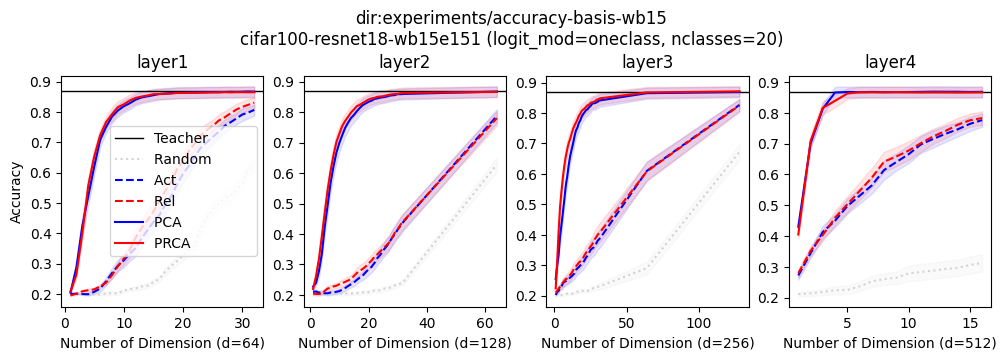

In [42]:
accuracy_curve(
    arch="cifar100-resnet18-wb15e151",
    layers_and_factors = [
        ("layer1", 2),
        ("layer2", 2),
        ("layer3", 2),
        ("layer4", 32)
    ],
    logit_mod="oneclass",
)

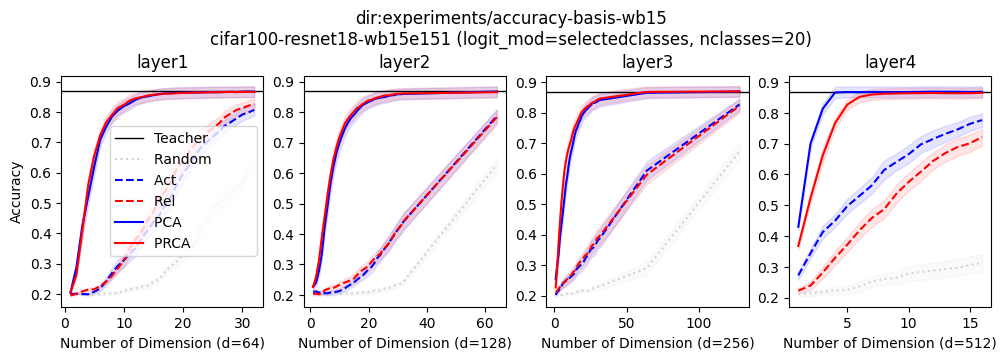

In [41]:
accuracy_curve(
    arch="cifar100-resnet18-wb15e151",
    layers_and_factors = [
        ("layer1", 2),
        ("layer2", 2),
        ("layer3", 2),
        ("layer4", 32)
    ],
    logit_mod="selectedclasses",
)

## Compare to Train with `Adam`

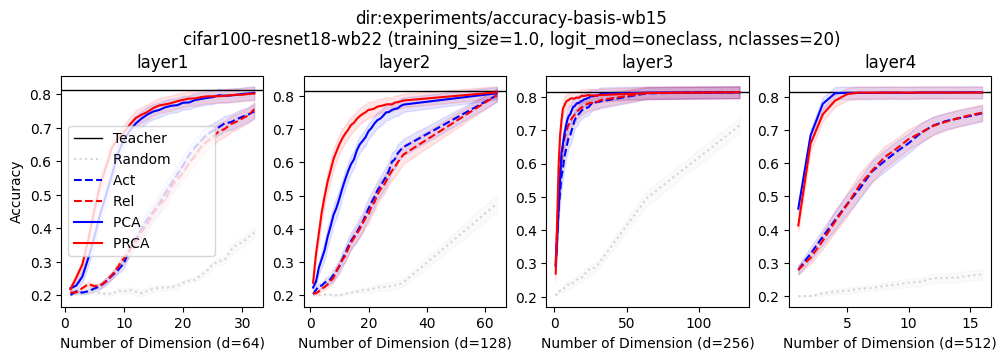

In [70]:
accuracy_curve(
    arch="cifar100-resnet18-wb22", # 200 epochs
    layers_and_factors = [
        ("layer1", 2),
        ("layer2", 2),
        ("layer3", 2),
        ("layer4", 32)
    ],
)

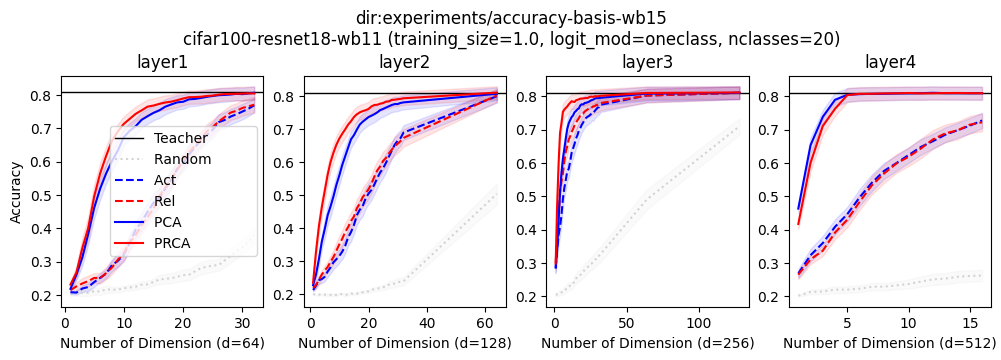

In [72]:
accuracy_curve(
    arch="cifar100-resnet18-wb11", # 100 epochs
    layers_and_factors = [
        ("layer1", 2),
        ("layer2", 2),
        ("layer3", 2),
        ("layer4", 32)
    ],
)